<a href="https://colab.research.google.com/github/lolndo/Basic_Networks2/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%D0%9E%D0%B1%D1%83%D1%87%D0%B0%D1%8E%D1%89%D0%B0%D1%8F%2C_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BE%D1%87%D0%BD%D0%B0%D1%8F_%D0%B8_%D1%82%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B2%D1%8B%D0%B1%D0%BE%D1%80%D0%BA%D0%B8_%D0%9F%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%9D%D0%A1_%D0%94%D0%97_Lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Задание

Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9** моделей нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке.  Используйте следующее деление: обучающая выборка - **50000** примеров, проверочная выборка - **10000** примеров, тестовая выборка - **10000** примеров.

2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведенных тестов.

# Шаблон ноутбука

##Импорт библиотек

In [ ]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam, Adadelta

# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Связь с google-диском
from google.colab import files

# Предварительная обработка данных
from sklearn import preprocessing

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from keras.datasets import fashion_mnist

# Отрисовывать изображения в ноутбуке, а не в консоль или файл
%matplotlib inline

##Описание базы

###База: одежда, обувь и аксессуары
- Датасет состоит из набора изображений одежды, обуви, аксессуаров и их классов.
- Изображения одного вида хранятся в numpy-массиве **(28, 28)** - **x_train, x_test**.
- База содержит **10** классов: (Футболка, Брюки, Пуловер, Платье, Пальто, Сандалии/Босоножки, Рубашка, Кроссовки, Сумочка, Ботильоны) - **y_train, y_test**.
- Примеров: train - **60000**, test - **10000**.

###Вывод примеров

In [ ]:
# Загрузка датасета
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Вывод размерностей выборок

print('Размер x_train:',x_train.shape)
print('Размер y_train:',y_train.shape)
print('Размер x_test:',x_test.shape)
print('Размер y_test:',y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер x_train: (60000, 28, 28)
Размер y_train: (60000,)
Размер x_test: (10000, 28, 28)
Размер y_test: (10000,)


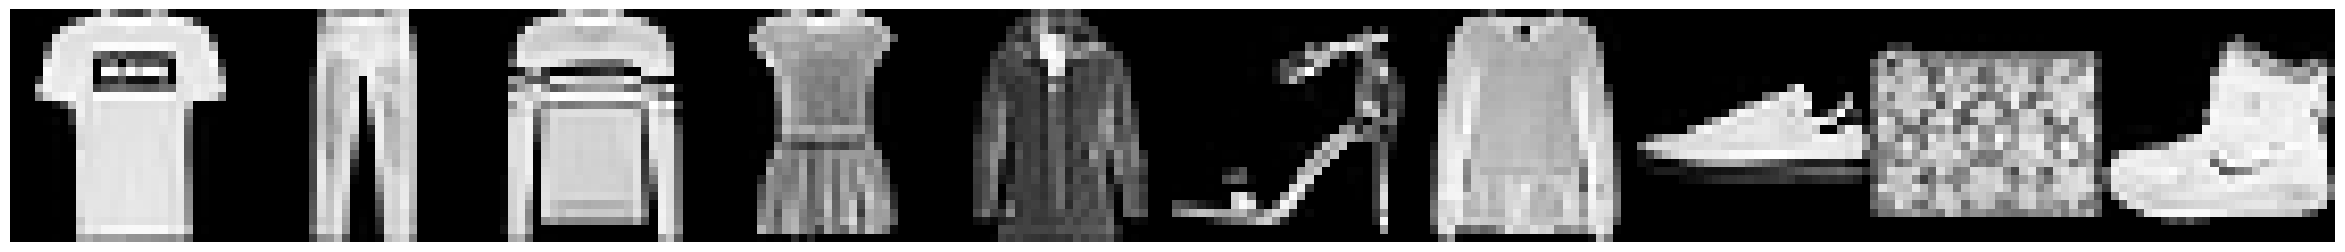

In [ ]:
# Выбор 1 изображения каждого класса
imgs = np.array([x_train[y_train==i][0] for i in range(10)])

# Соединение изображения в одну линию
imgs = np.concatenate(imgs, axis=1)

# Создание поля для изображения
plt.figure(figsize=(30, 6))

# Отрисовка итогового изображения
plt.imshow(imgs, cmap='Greys_r')

# Без сетки
plt.grid(False)

# Без осей
plt.axis('off')

# Вывод результата
plt.show()

In [ ]:
# Ваше решение

In [ ]:
#Подготовка данных
x_train = x_train.astype('float32') / 255.0  # Нормализация
x_test = x_test.astype('float32') / 255.0

# кодирование меток
y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)

# Разделение исходной обучающей выборки
from sklearn.model_selection import train_test_split
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train_cat, train_size=50000, random_state=42, stratify=y_train)

print('Размеры данных:')
print(f'Train: {x_train_split.shape[0]}, Val: {x_val.shape[0]}, Test: {x_test.shape[0]}')

Размеры данных:
Train: 50000, Val: 10000, Test: 10000


In [ ]:
from tensorflow.keras.layers import Flatten
architectures = [
    [('Dense', 32, 'relu')],                                      # 1 слой, 32 нейрона
    [('Dense', 128, 'relu')],                                     # 1 слой, 128
    [('Dense', 512, 'relu')],                                     # 1 слой, 512
    [('Dense', 128, 'relu'), ('Dense', 64, 'relu')],              # 2 слоя: 128→64
    [('Dense', 256, 'relu'), ('Dense', 128, 'relu')],             # 2 слоя: 256→128
    [('Dense', 512, 'relu'), ('Dense', 256, 'relu')],             # 2 слоя: 512→256
    [('Dense', 256, 'relu'), ('Dense', 128, 'relu'), ('Dense', 64, 'relu')],   # 3 слоя: 256→128→64
    [('Dense', 512, 'relu'), ('Dense', 256, 'relu'), ('Dense', 128, 'relu')],  # 3 слоя: 512→256→128
    [('Dense', 512, 'relu'), ('Dense', 512, 'relu'), ('Dense', 256, 'relu')]   # 3 слоя: 512→512→256
]

# ---------- Обучение и сбор результатов ----------
results = []

for i, layers_desc in enumerate(architectures):
    model = Sequential()

    model.add(Flatten(input_shape=(28, 28)))

    for layer_type, units, activation in layers_desc:
        model.add(Dense(units, activation=activation))

    # Выходной слой
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    # Короткая метка для отчёта
    arch_label = '→'.join(f'{units}' for _, units, _ in layers_desc)
    print(f'\nМодель {i+1}: {arch_label}')


    history = model.fit(
        x_train_split, y_train_split,
        batch_size=64,
        epochs=20,
        validation_data=(x_val, y_val),
        verbose=1
    )

    # Точность на проверочной выборке на последней эпохе
    val_acc = history.history['val_accuracy'][-1]

    # Оценка на тестовой выборке
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    results.append({
        'Архитектура': arch_label,
        'Число слоёв': len(layers_desc),
        'Val Accuracy': f'{val_acc:.4f}',
        'Test Accuracy': f'{test_acc:.4f}'
    })


Модель 1: 32
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7871 - loss: 0.6296 - val_accuracy: 0.8434 - val_loss: 0.4466
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8459 - loss: 0.4417 - val_accuracy: 0.8544 - val_loss: 0.4024
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8588 - loss: 0.4023 - val_accuracy: 0.8622 - val_loss: 0.3899
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8665 - loss: 0.3812 - val_accuracy: 0.8686 - val_loss: 0.3764
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8717 - loss: 0.3634 - val_accuracy: 0.8776 - val_loss: 0.3569
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8772 - loss: 0.3487 - val_accuracy: 0.8728 - val_loss: 0.3617
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8786 - loss: 0.3396 - val_accuracy: 0.8754 - val_loss: 0.3560
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8814 - loss: 0.3308 - va

In [ ]:
import pandas as pd
from IPython.display import display

df = pd.DataFrame(results)
display(df)

,Архитектура,Число слоёв,Val Accuracy,Test Accuracy
0,32,1,0.8862,0.8708
1,128,1,0.9010,0.8870
2,512,1,0.9025,0.8910
3,128→64,2,0.8942,0.8803
4,256→128,2,0.9003,0.8891
5,512→256,2,0.9040,0.8910
6,256→128→64,3,0.8993,0.8870
7,512→256→128,3,0.9017,0.8924
8,512→512→256,3,0.9046,0.8928
